<a href="https://colab.research.google.com/github/RTE404/NLP-Resume-Screening-App/blob/main/Resume_Screening_App.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPROVEMENT LOG:
1. Implemented Lemmatization
2. Configured the model to handle pdf, word or text files as input
3. Implemented GridSearchCV for hyperparameter tuning for SVM

**1. IMPORTING IMPORTANT LIBRARIES**

In [65]:
!pip install PyPDF2 python-docx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PyPDF2
import docx
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [66]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ResumeDataset.csv')
df.head()


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [67]:
df.shape

(962, 2)

In [68]:
df['Category'].value_counts()

,count
Category,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


**2. VISUALIZING OUR DATASET**

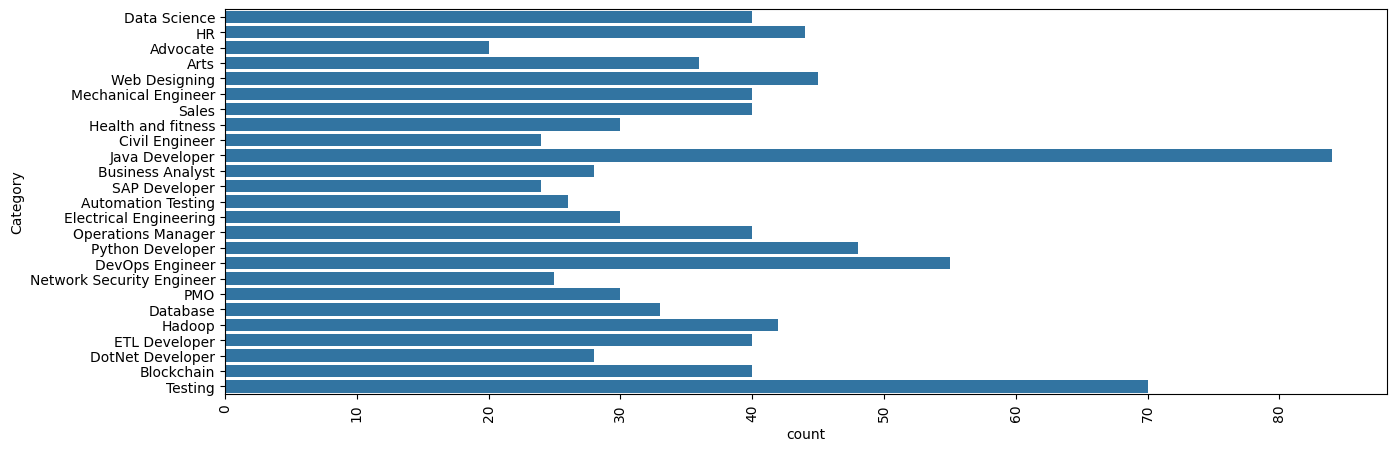

In [69]:
plt.figure(figsize=(15,5))
sns.countplot(df['Category'])
plt.xticks(rotation = 90)
plt.show()

In [70]:
df['Category'].unique()

array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
       'Mechanical Engineer', 'Sales', 'Health and fitness',
       'Civil Engineer', 'Java Developer', 'Business Analyst',
       'SAP Developer', 'Automation Testing', 'Electrical Engineering',
       'Operations Manager', 'Python Developer', 'DevOps Engineer',
       'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
       'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
      dtype=object)

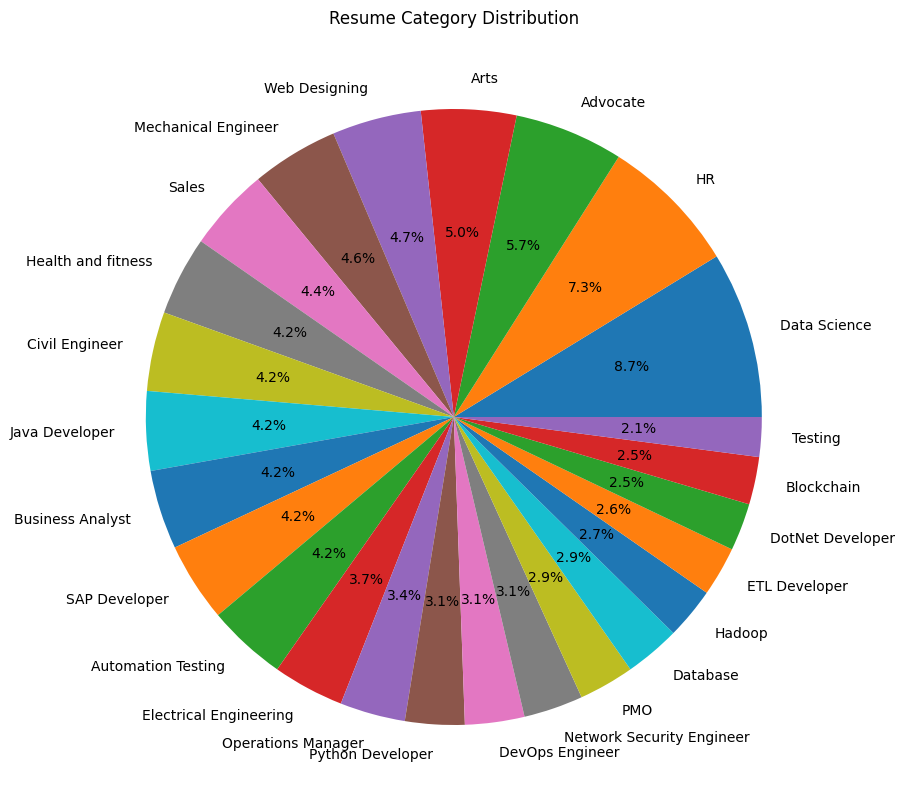

In [71]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize=(15,10))
plt.pie(counts, labels=labels, autopct='%1.1f%%')
plt.title('Resume Category Distribution')
plt.show()

**3. EXPLORING DIFFERENT RESUMES**

In [72]:
df['Category'][0]

'Data Science'

In [73]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

**4. CLEANING DATA:**

*   URLs
*   Hashtags
*   Mentions
*   Special Letters
*   Punctuations





In [74]:
def extract_text_from_file(file_path):

    # 1. Handle PDF
    if file_path.endswith('.pdf'):
        try:
            with open(file_path, 'rb') as f:
                pdf_reader = PyPDF2.PdfReader(f)
                text = ''
                for page in pdf_reader.pages:
                    text += page.extract_text() + " "
                return text
        except Exception as e:
            print(f"Error reading PDF: {e}")
            return ""

    # 2. Handle DOCX
    elif file_path.endswith('.docx'):
        try:
            doc = docx.Document(file_path)
            text = ' '.join([para.text for para in doc.paragraphs])
            return text
        except Exception as e:
            print(f"Error reading DOCX: {e}")
            return ""

    # 3. Handle TXT
    elif file_path.endswith('.txt'):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                return f.read()
        except Exception as e:
            print(f"Error reading TXT: {e}")
            return ""

    else:
        # Fallback: Assume it's a raw string if it's not a file path
        # This handles the case where you just pass "I am a java developer" directly
        return file_path


In [75]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def clean_resume(text):
    clean_text = re.sub(r'http\S+', '', text)
    clean_text = re.sub(r'RT|cc', '', clean_text)
    clean_text = re.sub(r'@\S+', '', clean_text)
    clean_text = re.sub(r'#\S+', '', clean_text)
    clean_text = re.sub(r'[' + re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~""") + r']', ' ', clean_text)
    clean_text = re.sub(r'[^\x00-\x7f]', ' ', clean_text)
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()

    clean_text = clean_text.lower()
    words = clean_text.split()

    # We lemmatize TWICE:
    # 1. As a Verb (v): catches "developing" -> "develop", "running" -> "run"
    # 2. As a Noun (n): catches "developers" -> "developer", "corporations" -> "corporation"

    lemmatized_words = []
    for word in words:
        if len(word) > 2:
            # First turn verbs into root form
            word = lemmatizer.lemmatize(word, pos='v')
            # Then fix plural nouns
            word = lemmatizer.lemmatize(word, pos='n')
            lemmatized_words.append(word)

    return " ".join(lemmatized_words)




<>:15: SyntaxWarning: invalid escape sequence '\]'
<>:15: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipython-input-4205448015.py:15: SyntaxWarning: invalid escape sequence '\]'
  clean_text = re.sub(r'[' + re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~""") + r']', ' ', clean_text)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [76]:
clean_resume("this @@## is my$$%%%## resume on website http://helloworld and")

'this resume website and'

In [77]:
sample = "I was developing a system for developers using Python."
print(clean_resume(sample))


be develop system for developer use python


In [78]:
df['Resume'] = df['Resume'].apply(lambda x : clean_resume(x))

In [79]:
df['Resume'][0]

'skill program language python panda numpy scipy scikit learn matplotlib sql java javascript jquery machine learn regression svm bay knn random forest decision tree boost technique cluster analysis word embed sentiment analysis natural language process dimensionality reduction topic model lda nmf pca neural net database visualization mysql sqlserver cassandra hbase elasticsearch plotly kibana matplotlib ggplot tableau others regular expression html cs angular logstash kafka python flask git docker computer vision open and understand deep learn education detail data science assurance associate data science assurance associate ernst young llp skill detail javascript exprience month jquery exprience month python exprience monthscompany detail company ernst young llp description fraud investigation and dispute service assurance technology assist review tar technology assist review assist aelerating the review process and run analytics and generate report core member team help develop autom

**5. CONVERTING WORDS INTO CATEGORICAL VALUES**

In [80]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['Category'])
df['Category'] = le.transform(df['Category'])
df['Category'].unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [81]:
# array(['Data Science', 'HR', 'Advocate', 'Arts', 'Web Designing',
#        'Mechanical Engineer', 'Sales', 'Health and fitness',
#        'Civil Engineer', 'Java Developer', 'Business Analyst',
#        'SAP Developer', 'Automation Testing', 'Electrical Engineering',
#        'Operations Manager', 'Python Developer', 'DevOps Engineer',
#        'Network Security Engineer', 'PMO', 'Database', 'Hadoop',
#        'ETL Developer', 'DotNet Developer', 'Blockchain', 'Testing'],
#       dtype=object)

**6. VECTORIZATION**

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=1500)

tfidf.fit(df['Resume'])
required_text = tfidf.transform(df['Resume'])


In [83]:
df

,Category,Resume
0,6,skill program language python panda numpy scip...
1,6,education detail may 2013 may 2017 uit rgpv da...
2,6,area interest deep learn control system design...
3,6,skill python sap hana tableau sap hana sql sap...
4,6,education detail mca ymcaust faridabad haryana...
...,...,...
957,23,computer skill proficient office word basic ex...
958,23,willingness aept the challenge positive think ...
959,23,personal skill quick learner eagerness learn n...
960,23,computer skill software knowledge power point ...


**7. SPLITTING**

In [84]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(required_text, df['Category'], test_size = 0.2, random_state = 42)

In [85]:
x_train.shape

(769, 1500)

In [86]:
x_test.shape

(193, 1500)

**8. TRAINING THE MODEL USING DIFFERENT TECHNIQUES**

In [87]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure that x_train and x_test are dense if they are sparse
x_train = x_train.toarray() if hasattr(x_train, 'toarray') else x_train
x_test = x_test.toarray() if hasattr(x_test, 'toarray') else x_test

# 1. Train KNeighborsClassifier
knn_model = OneVsRestClassifier(KNeighborsClassifier())
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)
print("\nKNeighborsClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_knn)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_knn)}")


KNeighborsClassifier Results:
Accuracy: 0.9637
Confusion Matrix:
[[ 3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2  0  0
   0]
 [ 0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 13  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0  

In [88]:
# 2. Train SVC
from sklearn.model_selection import GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC

# 1. Define the Parameter Grid
# These are the "knobs" we want to test
param_grid = {
    'estimator__C': [0.1, 1, 10, 100],          # Regularization (Relaxed -> Strict)
    'estimator__gamma': ['scale', 'auto'],      # Kernel coefficient
    'estimator__kernel': ['linear', 'rbf']      # Type of hyperplane
}

# 2. Initialize the Base Model
# Note: We wrap it in OneVsRest because our problem is multiclass
base_model = OneVsRestClassifier(SVC())

# 3. Setup GridSearchCV
# cv=5 means "5-Fold Cross Validation" (splits data 5 ways to be sure)
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,          # Use ALL CPU cores (speed up)
    verbose=2,          # Print progress log
    scoring='accuracy'  # Metric to optimize
)

# 4. Train
print("Starting Grid Search...")
grid_search.fit(x_train, y_train)

# 5. Get the Winner
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_:.4f}")

# 6. Save the Best Model
svc_model = grid_search.best_estimator_

# 7. Evaluate on Test Set (Final Verification)
y_pred_svc = svc_model.predict(x_test)
print("\nOptimized SVC Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svc)}")


Starting Grid Search...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'estimator__C': 1, 'estimator__gamma': 'scale', 'estimator__kernel': 'linear'}
Best Cross-Validation Score: 0.9961

Optimized SVC Results:
Accuracy: 0.9948
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         7
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         8
           8       1.00      0.93      0.96        14
           9       1.00      1.00      1.00         5
          10       1.00      1.00      1.00         7
          11       1.00      1.00      1.00         6
          12   

In [89]:
# 3. Train RandomForestClassifier
rf_model = OneVsRestClassifier(RandomForestClassifier())
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
print("\nRandomForestClassifier Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")


RandomForestClassifier Results:
Accuracy: 1.0000
Confusion Matrix:
[[ 3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  4  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  9  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  7  0  0  0  0  0  0  0  0  0  0  0  0  0
   0]
 [ 0  0  0  0  0  0  0  0  0  0  0  6  0  0  0  0  0

**9. SAVE THE MODEL**

In [90]:
import pickle
pickle.dump(tfidf,open('tfidf.pkl','wb'))
pickle.dump(svc_model, open('clf.pkl', 'wb'))
pickle.dump(le, open("encoder.pkl",'wb'))

**10. PREDICTION SYSTEM**

In [91]:
# Function to predict the category of a resume
def pred(input_resume):

    # Extract text (handles both file paths and raw text)
    extracted_text = extract_text_from_file(input_resume)

    # Check if extraction failed (empty string)
    if not extracted_text.strip():
        return "Error: Could not extract text from file or file is empty."


    # Preprocess the extracted text (e.g., cleaning, etc.)
    cleaned_text = clean_resume(extracted_text)

    # Vectorize the cleaned text using the same TF-IDF vectorizer used during training
    vectorized_text = tfidf.transform([cleaned_text])

    # Convert sparse matrix to dense
    vectorized_text = vectorized_text.toarray()

    # Prediction
    predicted_category = svc_model.predict(vectorized_text)

    # get name of predicted category
    predicted_category_name = le.inverse_transform(predicted_category)

    return predicted_category_name[0]  # Return the category name

In [92]:
myresume = """I am a data scientist specializing in machine
learning, deep learning, and computer vision. With
a strong background in mathematics, statistics,
and programming, I am passionate about
uncovering hidden patterns and insights in data.
I have extensive experience in developing
predictive models, implementing deep learning
algorithms, and designing computer vision
systems. My technical skills include proficiency in
Python, Sklearn, TensorFlow, and PyTorch.
What sets me apart is my ability to effectively
communicate complex concepts to diverse
audiences. I excel in translating technical insights
into actionable recommendations that drive
informed decision-making.
If you're looking for a dedicated and versatile data
scientist to collaborate on impactful projects, I am
eager to contribute my expertise. Let's harness the
power of data together to unlock new possibilities
and shape a better future.
Contact & Sources
Email: 611noorsaeed@gmail.com
Phone: 03442826192
Github: https://github.com/611noorsaeed
Linkdin: https://www.linkedin.com/in/noor-saeed654a23263/
Blogs: https://medium.com/@611noorsaeed
Youtube: Artificial Intelligence
ABOUT ME
WORK EXPERIENCE
SKILLES
NOOR SAEED
LANGUAGES
English
Urdu
Hindi
I am a versatile data scientist with expertise in a wide
range of projects, including machine learning,
recommendation systems, deep learning, and computer
vision. Throughout my career, I have successfully
developed and deployed various machine learning models
to solve complex problems and drive data-driven
decision-making
Machine Learnine
Deep Learning
Computer Vision
Recommendation Systems
Data Visualization
Programming Languages (Python, SQL)
Data Preprocessing and Feature Engineering
Model Evaluation and Deployment
Statistical Analysis
Communication and Collaboration
"""

pred(myresume)

'Data Science'

In [93]:
myresume = """
Jane Smith is a certified personal trainer with over 5 years of experience in helping individuals achieve their fitness goals. Specializing in weight loss, strength training, and sports conditioning, Jane has developed personalized workout routines for clients of all ages and fitness levels. She has extensive knowledge in nutrition and exercise science, and uses this to create holistic health and fitness programs that are tailored to individual needs.

Jane holds a degree in Exercise Science and is a certified trainer through the National Academy of Sports Medicine (NASM). She has worked with athletes, seniors, and individuals with chronic health conditions, helping them improve their physical well-being and overall quality of life.

Her expertise includes:
- Weight Loss and Body Composition
- Strength Training and Resistance Exercises
- Cardio Conditioning
- Nutrition Coaching and Meal Planning
- Injury Prevention and Rehabilitation
- Functional Movement and Flexibility Training
- Group Fitness Classes

Certifications:
- Certified Personal Trainer, NASM
- CPR and First Aid Certified
- Yoga Instructor (200-Hour Certification)

Education:
BSc in Exercise Science, ABC University, 2014-2018

Work Experience:
- Personal Trainer at XYZ Fitness Gym (2018-Present)
- Fitness Coach at Wellness Center (2016-2018)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

# Now, test the model with the Health and Fitness-focused resume
pred(myresume)

'Health and fitness'

In [94]:
myresume = """
John Doe is an experienced Network Security Engineer with over 7 years of expertise in designing, implementing, and managing network security infrastructures. Specializing in safeguarding critical network systems, John has worked with various organizations to protect against cyber threats, data breaches, and unauthorized access. He is proficient in deploying firewalls, intrusion detection systems (IDS), VPNs, and network monitoring tools to ensure the integrity and security of networks.

John holds a degree in Computer Science and certifications in several cybersecurity domains, including Certified Information Systems Security Professional (CISSP), Certified Ethical Hacker (CEH), and Cisco Certified Network Associate (CCNA). He has extensive experience in troubleshooting and resolving network vulnerabilities, and has played a key role in conducting security audits and risk assessments.

Key Skills:
- Network Security Architecture
- Firewall Management and Configuration
- Intrusion Detection and Prevention Systems (IDS/IPS)
- Virtual Private Networks (VPNs)
- Security Audits and Risk Assessments
- Cybersecurity Incident Response
- Network Monitoring and Traffic Analysis
- Vulnerability Assessment and Penetration Testing
- Data Encryption and Secure Communications

Certifications:
- CISSP (Certified Information Systems Security Professional)
- CEH (Certified Ethical Hacker)
- CCNA (Cisco Certified Network Associate)
- CompTIA Security+

Education:
BSc in Computer Science, XYZ University, 2012-2016

Professional Experience:
- Network Security Engineer at ABC Corp (2016-Present)
- IT Security Specialist at DEF Solutions (2014-2016)

Languages:
- English (Fluent)
- French (Intermediate)
"""

# Now, test the model with the Network Security Engineer-focused resume
pred(myresume)

'Network Security Engineer'

In [95]:
myresume = """
Sarah Williams is a dedicated and skilled advocate with over 10 years of experience in providing legal representation to clients across various sectors, including criminal law, civil litigation, and family law. With a deep understanding of legal procedures and case law, Sarah has successfully handled numerous cases in the courtroom, negotiating favorable settlements and providing expert legal advice to individuals and businesses.

She holds a law degree from XYZ University and is a licensed attorney, practicing law in multiple jurisdictions. Sarah is passionate about ensuring justice is served and strives to make legal processes more accessible to her clients. She is known for her excellent research and analytical skills, attention to detail, and commitment to upholding the law with integrity.

Key Skills:
- Criminal Law
- Civil Litigation
- Family Law
- Contract Law
- Legal Research and Writing
- Courtroom Advocacy
- Legal Counseling and Advice
- Client Relationship Management
- Legal Compliance and Regulations
- Negotiation and Settlement

Certifications and Licenses:
- Licensed Attorney at Law, XYZ State Bar
- Certification in Criminal Law, XYZ University

Education:
JD in Law, XYZ University, 2010-2013

Professional Experience:
- Senior Advocate at ABC Law Firm (2016-Present)
- Associate Advocate at DEF Legal Group (2013-2016)

Languages:
- English (Fluent)
- Spanish (Conversational)
"""

# Now, test the model with the Advocate-focused resume
pred(myresume)

'Advocate'

In [96]:
pred('/content/Resume_SWE.pdf')

Error reading PDF: [Errno 2] No such file or directory: '/content/Resume_SWE.pdf'


'Error: Could not extract text from file or file is empty.'